# Experiment 3: Logprob Mean Baseline

| | |
|---|---|
| **Author** | Elad Moshe |
| **Supervisors** | Prof. Luciano Dyballa & Prof. Andrea Cremaschi |
| **Institution** | IE Madrid — MSc Computer Science |
| **Date** | June 2026 |
| **Priority** | MUST-HAVE (Behavioral baseline) |

> ---
> **AI Assistance Disclaimer:** Portions of this notebook (code scaffolding, documentation, and structural outlines) were generated with the assistance of Claude (Anthropic). All experimental design, interpretation, and conclusions are the author's own. AI-generated content has been reviewed and validated by the author before inclusion.
> ---

## Notebook Overview

**Purpose:** Establish a behavioral (non-mechanistic) baseline. Mean log-probability of the
generated response as a scalar correctness predictor, under CoT and NoCoT conditions.

**Key design:** `mean_lp` is already recorded by Exp1 during baseline generation — this
experiment reuses those cached parquets and requires **no extra model inference** when
Exp1 has been run first.

| Parameter | Value |
|---|---|
| Dataset | GSM8K test set, n = 400, seed = 42 |
| Model | Gemma-2-2B-IT (`google/gemma-2-2b-it`) |
| Feature | `mean_lp` — mean log-probability over generated tokens (scalar per chain) |
| Classifier | L2 LogReg, C = 0.1, `class_weight='balanced'`, 5-fold stratified CV |
| Metric | AUROC (primary) + Mann-Whitney U (distributional test) |

**Caching strategy:** Every expensive step is cached. Re-running skips completed work.

| Cache / Figure file | Content |
|---|---|
| `cache/lr_results.csv` | CV-AUROC for CoT and NoCoT conditions |
| `cache/comparison_table.csv` | Side-by-side comparison table |
| `cache/mw_tests.csv` | Mann-Whitney U test results |
| `figures/fig1_logprob_distribution.png` | Violin + strip plot (correct vs incorrect) |
| `figures/fig2_roc_curves.png` | ROC curves for both conditions |

## Installation

Run this cell **once**, then restart the kernel (`Runtime → Restart session`).

> If packages are already installed (e.g. in a pre-configured Colab environment),
> this cell is safe to skip — re-running it will simply confirm the versions.

**Before running the model fallback** (only needed if Exp1 cache is absent):
1. Accept the Gemma licence at `huggingface.co/google/gemma-2-2b-it`
2. Create a **Read** token at `huggingface.co/settings/tokens`
3. In Colab: Secrets icon → `+ Add new secret` → Name: `HF_TOKEN`, toggle **Notebook access** ON

In [ ]:
# ── Install required packages ─────────────────────────────────────────────
# Run this cell ONCE, then Runtime → Restart session.
# Colab ships torchvision/torchaudio with a binary mismatch vs its torch build;
# uninstalling them prevents an ImportError when transformers loads later.

import subprocess, sys

subprocess.run([sys.executable, '-m', 'pip', 'uninstall', '-y',
                'torchvision', 'torchaudio'], capture_output=True)

subprocess.run([sys.executable, '-m', 'pip', 'install', '-q',
    'transformers==4.44.2',
    'datasets>=2.19.0',
    'accelerate>=0.29.0',
    'huggingface_hub>=0.23.0',
    'safetensors',
    'scikit-learn',
    'scipy',
    'seaborn',
    'pyarrow',
    'tqdm',
    'ipywidgets',
], check=True)

print('Packages installed.')
print('\n>>> Restart the kernel now (Runtime → Restart session), then run from Setup. <<<')

Packages installed.

>>> Restart the kernel now (Runtime → Restart session), then run from Setup. <<<


## 0. Setup & Imports

In [ ]:
# ── Colab: neutralise binary-incompatible media libraries ────────────────
import sys, importlib.util

def _neutralise(pkg: str) -> None:
    try:
        __import__(pkg)
    except (OSError, ImportError):
        for key in list(sys.modules.keys()):
            if key == pkg or key.startswith(pkg + '.'):
                del sys.modules[key]
        _orig = importlib.util.find_spec
        def _patched(name, *a, **kw):
            if name == pkg or name.startswith(pkg + '.'):
                return None
            return _orig(name, *a, **kw)
        importlib.util.find_spec = _patched

_neutralise('torchaudio')
_neutralise('torchvision')

# ── Standard imports ──────────────────────────────────────────────────────
import os, re, json, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import torch
from pathlib import Path
from scipy import stats
from tqdm.auto import tqdm
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import roc_auc_score, roc_curve

warnings.filterwarnings('ignore')

# ── Experiment constants ───────────────────────────────────────────────────
SEED     = 42
N_SAMPLE = 400
MODEL_ID = 'google/gemma-2-2b-it'
MAX_NEW  = 512

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'

np.random.seed(SEED)
torch.manual_seed(SEED)
print(f'Device: {DEVICE}')
print('Imports done. Run the Google Drive cell next to set up persistent paths.')

Device: cuda
Imports done. Run the Google Drive cell next to set up persistent paths.


## 0b. Google Drive — Persistent Storage

**All cache files and figures are written to Google Drive** via your synced
`Computers/` section — they survive session disconnects completely.

The cell below mounts Drive and **auto-detects** this notebook's folder by name,
so no hardcoded paths are needed. It searches `/content/drive/Computers/` first
(Google Drive for Desktop sync), then falls back to `/content/drive/MyDrive/`.

Output structure created automatically:

```
experiments/
└── exp3_logprob_mean/          ← notebook lives here (auto-detected)
    └── backup/
        ├── cache/              ← lr_results.csv, comparison_table.csv, mw_tests.csv, *.parquet
        └── figures/            ← fig1_logprob_distribution.png, fig2_roc_curves.png
```

Exp1's cache is read from its sibling `backup/cache/` — both must be on Drive.

> **On reconnect:** run **Setup → Drive → Section 1 → …** in order.
> All caches are detected and sections that already completed are skipped.

In [ ]:
from google.colab import drive
from pathlib import Path
import subprocess

drive.mount('/content/drive')

# ── Auto-detect this notebook's folder in Drive ───────────────────────────
# Strategy 1 (fast): walk one level under MyDrive — catches shortcuts directly.
# Strategy 2 (fallback): find -L to follow symlinks inside Computers.
def _find_notebook_dir(name: str) -> Path:
    my_drive = Path('/content/drive/MyDrive')
    if my_drive.exists():
        top = sorted(d for d in my_drive.iterdir() if d.is_dir())
        print(f'  MyDrive entries: {[d.name for d in top]}')
        for entry in top:
            if entry.name == name:
                return entry
            candidate = entry / name
            if candidate.exists():
                return candidate
    else:
        print('  /content/drive/MyDrive not found — check Drive mount.')
    roots = ([str(my_drive)] if my_drive.exists() else [])
    computers = Path('/content/drive/Computers')
    if computers.exists():
        roots.append(str(computers))
    for root in roots:
        print(f'  Falling back to find -L in {Path(root).name}...')
        r = subprocess.run(
            ['find', '-L', root, '-maxdepth', '20', '-type', 'd', '-name', name],
            capture_output=True, text=True, timeout=240,
        )
        hits = [p.strip() for p in r.stdout.strip().split('\n')
                if p.strip() and '/backup' not in p and '/.Trash' not in p]
        if hits:
            return Path(hits[0])
    top_names = ([d.name for d in my_drive.iterdir()] if my_drive.exists() else [])
    raise RuntimeError(
        f'Could not find "{name}" in Drive.\n'
        f'  MyDrive contents: {top_names}\n\n'
        'To fix — pick ONE option:\n'
        '  A) Shortcut: drive.google.com → find the "experiments" folder\n'
        '     → Right-click → Organize → Add shortcut → My Drive\n'
        '     Then re-run this cell.\n\n'
        '  B) Manual override — add this line BEFORE the _find_notebook_dir() call:\n'
        '     NOTEBOOK_DIR = Path("/content/drive/MyDrive/<folder_in_list_above>/exp3_logprob_mean")\n'
        '     (use the MyDrive contents list above to find the right parent folder)'
    )


print('Auto-detecting notebook folder in Drive...')
NOTEBOOK_DIR = _find_notebook_dir('exp3_logprob_mean')

BACKUP_DIR  = NOTEBOOK_DIR / 'backup'
CACHE_DIR   = BACKUP_DIR / 'cache'
FIGURES_DIR = BACKUP_DIR / 'figures'

# Exp1 activations — try canonical path first, fall back to old location
_exp1_new = NOTEBOOK_DIR.parent / 'exp1_residual_stream_regression' / 'backup' / 'cache'
_exp1_old = Path('/content/drive/MyDrive/exp1_cache')
if _exp1_new.exists():
    EXP1_CACHE = _exp1_new
elif _exp1_old.exists():
    print(f'  exp1 cache found at old location: {_exp1_old}')
    print(f'  (Run exp1 migration cell to move to canonical path — optional)')
    EXP1_CACHE = _exp1_old
else:
    EXP1_CACHE = _exp1_new

CACHE_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

assert '/content/drive/' in str(CACHE_DIR), (
    'CACHE_DIR is not on Google Drive — run the Drive mount cell first.'
)

print(f'\nDrive ready.')
print(f'  Notebook:   {NOTEBOOK_DIR}')
print(f'  Cache:      {CACHE_DIR}')
print(f'  Figures:    {FIGURES_DIR}')
print(f'  Exp1 cache: {EXP1_CACHE}  (exists={EXP1_CACHE.exists()})')

Mounted at /content/drive
Auto-detecting notebook folder in Drive...
  MyDrive entries: ['Colab Notebooks', 'Elad Moshe - MSc in CS', 'Research Capstone - Elad (LLM Reasoning)', 'University', 'exp1_cache', 'exp1_figures', 'experiments', 'h1_checkpoints', 'h1_runs', 'research capstone', 'אלעד משה - תואר שני', 'אלעד משה - תואר שני (1)', 'דרייב מחו"ג', 'כספות', 'מדמ"ח', 'מדעי המחשב', 'מדעי המחשב ישן ', 'מעבדות עותק', 'מעבדות פיזיקה אלעד משה', 'מערכות הפעלה', 'מערכות הפעלה (1)', 'סרטים להגות צבאית', 'פייתון תיכון', 'רב תחומי', 'שנה שלישית - חבצלות', 'תיק השקעות', 'תיקיית יב - תמונות']
  exp1 cache found at old location: /content/drive/MyDrive/exp1_cache
  (Run exp1 migration cell to move to canonical path — optional)

Drive ready.
  Notebook:   /content/drive/MyDrive/experiments/exp3_logprob_mean
  Cache:      /content/drive/MyDrive/experiments/exp3_logprob_mean/backup/cache
  Figures:    /content/drive/MyDrive/experiments/exp3_logprob_mean/backup/figures
  Exp1 cache: /content/drive/MyDri

## 1. Load Responses (with Logprob Mean)

`mean_lp` (mean log-probability over generated tokens, scalar per chain) is already
computed by Exp1 during baseline generation. This section loads those cached responses —
**no model inference required** if Exp1 has been run first.

| Shared cache path | Content |
|---|---|
| `.../exp1_residual_stream_regression/cache/gsm8k_sample_400.parquet` | 400 sampled problems |
| `.../exp1_residual_stream_regression/cache/responses_cot.parquet` | CoT responses + `mean_lp` |
| `.../exp1_residual_stream_regression/cache/responses_nocot.parquet` | NoCoT responses + `mean_lp` |

**Fallback:** If Exp1 has not been run, a lightweight generation pass is executed here.
Only `mean_lp` and `correct` are captured — activation extraction (the expensive step in
Exp1) is skipped. Results are saved to this experiment's `cache/` directory.

> Estimated generation time (fallback only): ~30–60 min per condition on GPU.

In [ ]:
# ── Path resolution: prefer Exp1 cache, fall back to local ───────────────
def _resolve(filename: str) -> Path:
    """Return Exp1 path if it exists, otherwise this experiment's local cache path."""
    exp1_path  = EXP1_CACHE / filename
    local_path = CACHE_DIR  / filename
    return exp1_path if exp1_path.exists() else local_path


SAMPLE_PATH = _resolve('gsm8k_sample_400.parquet')
COT_PATH    = _resolve('responses_cot.parquet')
NOCOT_PATH  = _resolve('responses_nocot.parquet')

print(f'GSM8K sample:    {SAMPLE_PATH}  (exists={SAMPLE_PATH.exists()})')
print(f'CoT responses:   {COT_PATH}  (exists={COT_PATH.exists()})')
print(f'NoCoT responses: {NOCOT_PATH}  (exists={NOCOT_PATH.exists()})')

# ── Case A: cached responses found ────────────────────────────────────────
if COT_PATH.exists() and NOCOT_PATH.exists():
    df_cot   = pd.read_parquet(COT_PATH)
    df_nocot = pd.read_parquet(NOCOT_PATH)
    print(f'\n✓ Loaded CoT responses   ({len(df_cot)} rows)')
    print(f'✓ Loaded NoCoT responses ({len(df_nocot)} rows)')
    assert 'mean_lp' in df_cot.columns,   'mean_lp missing from CoT cache — re-run Exp1'
    assert 'mean_lp' in df_nocot.columns, 'mean_lp missing from NoCoT cache — re-run Exp1'
    print('✓ mean_lp column verified in both conditions')

# ── Case B: no cache — run lightweight generation ─────────────────────────
else:
    print('\nExp1 responses not found → running lightweight generation.')
    print('This captures mean_lp + correctness only (no activation extraction).')

    import huggingface_hub
    from datasets import load_dataset as _load_ds
    from transformers import AutoTokenizer, AutoModelForCausalLM

    # ── Token authentication ───────────────────────────────────────────────
    try:
        from google.colab import userdata
        hf_token = userdata.get('HF_TOKEN').strip()
        print('HF token loaded from Colab Secrets.')
    except Exception:
        from getpass import getpass
        hf_token = getpass('Paste HuggingFace token: ').strip()

    os.environ['HF_TOKEN'] = hf_token
    huggingface_hub.login(token=hf_token, add_to_git_credential=False)

    # ── Load model ─────────────────────────────────────────────────────────
    print(f'\nLoading tokenizer and model: {MODEL_ID}  (~3 min on first run)')
    tokenizer = AutoTokenizer.from_pretrained(MODEL_ID, token=hf_token)
    model = AutoModelForCausalLM.from_pretrained(
        MODEL_ID,
        torch_dtype=torch.float16,
        device_map='auto',
        token=hf_token,
    )
    model.eval()
    print(f'Model ready on: {next(model.parameters()).device}')

    # ── Dataset ────────────────────────────────────────────────────────────
    if SAMPLE_PATH.exists():
        df_sample = pd.read_parquet(SAMPLE_PATH)
        print(f'Loaded dataset sample: {len(df_sample)} problems')
    else:
        print('Downloading GSM8K test set...')
        ds = _load_ds('openai/gsm8k', 'main', split='test')
        rng  = np.random.default_rng(SEED)
        idxs = sorted(rng.choice(len(ds), size=N_SAMPLE, replace=False).tolist())
        df_sample = pd.DataFrame([{
            'gsm8k_idx': i,
            'row_id':    n,
            'problem':   ds[i]['question'],
            'gold_answer': ds[i]['answer'].split('####')[-1].strip(),
        } for n, i in enumerate(idxs)])
        save_path = CACHE_DIR / 'gsm8k_sample_400.parquet'
        df_sample.to_parquet(save_path, index=False)
        SAMPLE_PATH = save_path
        print(f'Saved {len(df_sample)} problems → {save_path}')

    # ── Prompt templates — must match Exp1 exactly ─────────────────────────
    def make_cot_prompt(problem: str) -> str:
        return (
            '<start_of_turn>user\n'
            'Solve this math problem step by step. '
            'Show your full working, then write your final answer inside \\boxed{}.\n\n'
            f'Problem: {problem}\n'
            '<end_of_turn>\n<start_of_turn>model\n'
        )

    def make_nocot_prompt(problem: str) -> str:
        return (
            '<start_of_turn>user\n'
            'Solve this math problem. '
            'Output ONLY your final numerical answer inside \\boxed{}. No working shown.\n\n'
            f'Problem: {problem}\n'
            '<end_of_turn>\n<start_of_turn>model\n'
        )

    # ── Answer extraction ──────────────────────────────────────────────────
    _BOXED_RE = re.compile(r'\\boxed\{([^}]*)\}')
    _NUM_RE   = re.compile(r'-?\d+(?:\.\d+)?')

    def extract_answer(text: str):
        m = _BOXED_RE.findall(text)
        if m:
            raw = m[-1].strip().replace(',', '')
            try:    return float(raw)
            except: return raw
        nums = _NUM_RE.findall(text.replace(',', ''))
        if nums:
            try:    return float(nums[-1])
            except: pass
        return None

    def is_correct(pred, gold: str) -> bool:
        if pred is None: return False
        try:    return abs(float(pred) - float(gold.replace(',', ''))) < 1e-3
        except: return str(pred).strip() == gold.strip()

    # ── Lightweight generation: mean_lp + correctness only ────────────────
    def generate_one(prompt: str) -> dict:
        enc = tokenizer(prompt, return_tensors='pt').to(DEVICE)
        with torch.no_grad():
            out = model.generate(
                enc['input_ids'],
                attention_mask=enc['attention_mask'],
                max_new_tokens=MAX_NEW,
                do_sample=False,
                pad_token_id=tokenizer.eos_token_id,
                return_dict_in_generate=True,
                output_scores=True,
            )
        gen_ids = out.sequences[0, enc['input_ids'].shape[1]:]
        text    = tokenizer.decode(gen_ids, skip_special_tokens=True)
        lps     = [
            torch.log_softmax(score[0], dim=-1)[tok_id].item()
            for score, tok_id in zip(out.scores, gen_ids)
        ]
        return {
            'response_text': text,
            'mean_lp':       float(np.mean(lps)) if lps else float('nan'),
            'n_tokens':      len(lps),
        }

    def run_condition(name: str, prompt_fn, save_path: Path) -> pd.DataFrame:
        records = []
        for _, row in tqdm(df_sample.iterrows(), total=len(df_sample), desc=name):
            r    = generate_one(prompt_fn(row['problem']))
            pred = extract_answer(r['response_text'])
            r.update({
                'row_id':      row['row_id'],
                'gold_answer': row['gold_answer'],
                'pred_answer': str(pred),
                'correct':     is_correct(pred, row['gold_answer']),
            })
            records.append(r)
        df = pd.DataFrame(records)
        df.to_parquet(save_path, index=False)
        print(f'[{name}]  accuracy={df["correct"].mean():.1%}  →  {save_path}')
        return df

    df_cot   = run_condition('cot',   make_cot_prompt,   CACHE_DIR / 'responses_cot.parquet')
    df_nocot = run_condition('nocot', make_nocot_prompt, CACHE_DIR / 'responses_nocot.parquet')

# ── Summary ────────────────────────────────────────────────────────────────
print('\n' + '═'*60)
print('  RESPONSE SUMMARY')
print('═'*60)
for label, df_resp in [('CoT', df_cot), ('NoCoT', df_nocot)]:
    acc   = df_resp['correct'].mean()
    lp_c  = df_resp[df_resp.correct]['mean_lp'].mean()
    lp_i  = df_resp[~df_resp.correct]['mean_lp'].mean()
    print(f'  {label:5s}  acc={acc:.1%}  '
          f'mean_lp|correct={lp_c:.3f}  mean_lp|incorrect={lp_i:.3f}')
print('═'*60)

GSM8K sample:    /content/drive/MyDrive/exp1_cache/gsm8k_sample_400.parquet  (exists=True)
CoT responses:   /content/drive/MyDrive/exp1_cache/responses_cot.parquet  (exists=True)
NoCoT responses: /content/drive/MyDrive/exp1_cache/responses_nocot.parquet  (exists=True)

✓ Loaded CoT responses   (400 rows)
✓ Loaded NoCoT responses (400 rows)
✓ mean_lp column verified in both conditions

════════════════════════════════════════════════════════════
  RESPONSE SUMMARY
════════════════════════════════════════════════════════════
  CoT    acc=51.0%  mean_lp|correct=-0.080  mean_lp|incorrect=-0.113
  NoCoT  acc=8.0%  mean_lp|correct=-0.086  mean_lp|incorrect=-0.164
════════════════════════════════════════════════════════════


## 2. Logistic Regression — CoT & NoCoT (Logprob Mean)

Scalar logistic regression: `mean_lp` → `correct/incorrect` for both conditions.

- **Classifier:** L2-regularised LogReg, C = 0.1, `class_weight='balanced'`
- **Evaluation:** 5-fold stratified cross-validation, mean AUROC
- **Shuffled baseline:** Same pipeline with randomly permuted labels → expected AUROC ≈ 0.50

Both conditions are computed in this section and cached to `cache/lr_results.csv`.
Subsequent sections load from this cache — no redundant computation.

In [ ]:
RESULTS_PATH = CACHE_DIR / 'lr_results.csv'


def auroc_cv(X: np.ndarray, y: np.ndarray,
             C: float = 0.1, n_splits: int = 5,
             shuffle: bool = False, seed: int = SEED) -> float:
    """5-fold stratified CV → mean AUROC. shuffle=True gives the empirical chance baseline."""
    if shuffle:
        rng = np.random.default_rng(seed)
        y   = rng.permutation(y)
    min_class = min(int(y.sum()), int(len(y) - y.sum()))
    if min_class < n_splits:
        return float('nan')
    lr = LogisticRegression(
        C=C, class_weight='balanced',
        max_iter=2000, solver='lbfgs', random_state=seed,
    )
    cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=seed)
    return float(cross_val_score(lr, X, y, cv=cv, scoring='roc_auc').mean())


if RESULTS_PATH.exists():
    df_lr = pd.read_csv(RESULTS_PATH)
    print(f'Loaded cached LR results ({len(df_lr)} rows).')
else:
    records = []
    for cond, df_resp in [('cot', df_cot), ('nocot', df_nocot)]:
        y = df_resp['correct'].astype(int).values
        X = df_resp['mean_lp'].values.reshape(-1, 1)  # scalar feature

        auroc      = auroc_cv(X, y, shuffle=False)
        auroc_shuf = auroc_cv(X, y, shuffle=True)

        records.append({
            'condition':      cond,
            'feature':        'mean_lp',
            'auroc':          auroc,
            'auroc_shuffled': auroc_shuf,
            'n_correct':      int(y.sum()),
            'n_total':        int(len(y)),
            'accuracy':       float(y.mean()),
        })
        print(f'[{cond:5s}]  AUROC={auroc:.4f}  shuffled={auroc_shuf:.4f}  '
              f'correct={y.sum()}/{len(y)} ({y.mean():.1%})')

    df_lr = pd.DataFrame(records)
    df_lr.to_csv(RESULTS_PATH, index=False)
    print(f'\n✓ Saved LR results → {RESULTS_PATH}')

pd.set_option('display.float_format', '{:.4f}'.format)
print('\nFull results table:')
print(df_lr.to_string(index=False))

[cot  ]  AUROC=0.6916  shuffled=0.4577  correct=204/400 (51.0%)
[nocot]  AUROC=0.7151  shuffled=0.5809  correct=32/400 (8.0%)

✓ Saved LR results → /content/drive/MyDrive/experiments/exp3_logprob_mean/backup/cache/lr_results.csv

Full results table:
condition feature  auroc  auroc_shuffled  n_correct  n_total  accuracy
      cot mean_lp 0.6916          0.4577        204      400    0.5100
    nocot mean_lp 0.7151          0.5809         32      400    0.0800


## 3. Primary Comparison — CoT vs NoCoT

Side-by-side comparison of `mean_lp` AUROC for both conditions, plus the
Δ = AUROC_CoT − AUROC_NoCoT gap.

**Interpretation guide:**
- Δ > 0: CoT logprob mean is a stronger correctness predictor than NoCoT
- Δ ≈ 0: The scalar signal is equally informative under both prompting styles
- Δ < 0: NoCoT produces a stronger mean_lp signal (may indicate CoT token-count
  dilution — longer generation dilutes the mean with neutral/filler tokens)

In [ ]:
cot_row   = df_lr[df_lr.condition == 'cot'].iloc[0]
nocot_row = df_lr[df_lr.condition == 'nocot'].iloc[0]

delta = cot_row['auroc'] - nocot_row['auroc']

print('═'*65)
print('  EXP3 PRIMARY RESULT — Logprob Mean AUROC (Gemma-2-2B, GSM8K n=400)')
print('═'*65)
print(f'  CoT   AUROC : {cot_row["auroc"]:.4f}   '
      f'shuffled: {cot_row["auroc_shuffled"]:.4f}   acc={cot_row["accuracy"]:.1%}')
print(f'  NoCoT AUROC : {nocot_row["auroc"]:.4f}   '
      f'shuffled: {nocot_row["auroc_shuffled"]:.4f}   acc={nocot_row["accuracy"]:.1%}')
print(f'\n  Δ = AUROC_CoT − AUROC_NoCoT = {delta:+.4f}')
if abs(delta) < 0.01:
    print('  → No meaningful difference (|Δ| < 0.01).')
elif delta > 0:
    print('  → CoT mean_lp is a stronger correctness predictor.')
else:
    print('  → NoCoT mean_lp is a stronger predictor.\n'
          '     (CoT chains are longer — filler tokens may dilute the signal.)')
print('═'*65)

# ── Save comparison table ─────────────────────────────────────────────────
comparison = pd.DataFrame({
    'Condition':       ['CoT', 'NoCoT', 'Δ (CoT−NoCoT)'],
    'Accuracy':        [f'{cot_row["accuracy"]:.1%}',
                        f'{nocot_row["accuracy"]:.1%}', '—'],
    'AUROC (mean_lp)': [f'{cot_row["auroc"]:.4f}',
                        f'{nocot_row["auroc"]:.4f}', f'{delta:+.4f}'],
    'Shuffled AUROC':  [f'{cot_row["auroc_shuffled"]:.4f}',
                        f'{nocot_row["auroc_shuffled"]:.4f}', '—'],
    'N correct':       [int(cot_row['n_correct']),
                        int(nocot_row['n_correct']), '—'],
})
comparison_path = CACHE_DIR / 'comparison_table.csv'
comparison.to_csv(comparison_path, index=False)
print(f'\n✓ Saved comparison table → {comparison_path}')
print()
print(comparison.to_string(index=False))

═════════════════════════════════════════════════════════════════
  EXP3 PRIMARY RESULT — Logprob Mean AUROC (Gemma-2-2B, GSM8K n=400)
═════════════════════════════════════════════════════════════════
  CoT   AUROC : 0.6916   shuffled: 0.4577   acc=51.0%
  NoCoT AUROC : 0.7151   shuffled: 0.5809   acc=8.0%

  Δ = AUROC_CoT − AUROC_NoCoT = -0.0236
  → NoCoT mean_lp is a stronger predictor.
     (CoT chains are longer — filler tokens may dilute the signal.)
═════════════════════════════════════════════════════════════════

✓ Saved comparison table → /content/drive/MyDrive/experiments/exp3_logprob_mean/backup/cache/comparison_table.csv

    Condition Accuracy AUROC (mean_lp) Shuffled AUROC N correct
          CoT    51.0%          0.6916         0.4577       204
        NoCoT     8.0%          0.7151         0.5809        32
Δ (CoT−NoCoT)        —         -0.0236              —         —


## 4. Distribution Plots

Violin + strip plots of `mean_lp` for **correct vs incorrect** responses under each
condition.

- **Left panel:** CoT condition — is mean_lp systematically higher for correct chains?
- **Right panel:** NoCoT condition — does the same separation exist without reasoning?

Median lines (dashed black) highlight the central tendency difference. The CV-AUROC
from Section 2 is annotated in each panel for reference.

Figure saved to `figures/fig1_logprob_distribution.png`.

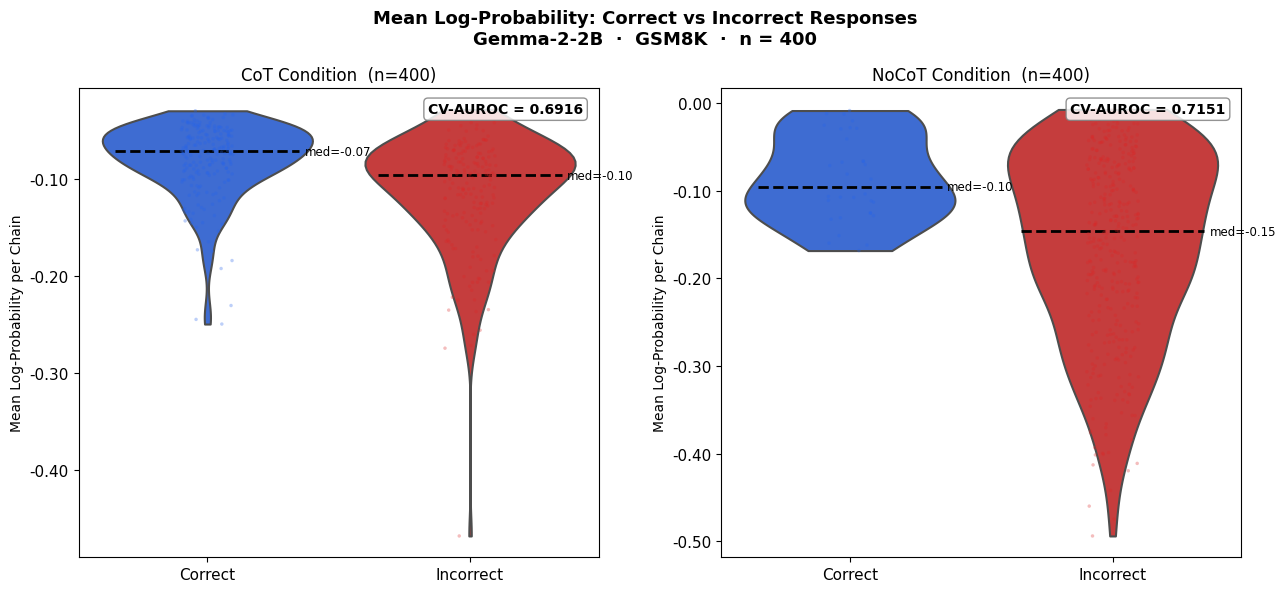

✓ Saved: /content/drive/MyDrive/experiments/exp3_logprob_mean/backup/figures/fig1_logprob_distribution.png


In [ ]:
FIG1_PATH = FIGURES_DIR / 'fig1_logprob_distribution.png'

if FIG1_PATH.exists():
    print(f'Distribution plot already saved → loading from disk: {FIG1_PATH}')
    from IPython.display import Image, display
    display(Image(str(FIG1_PATH)))
else:
    # Build a combined dataframe with condition and correctness labels
    plot_data = pd.concat([
        df_cot.assign(
            condition='CoT',
            label=df_cot['correct'].map({True: 'Correct', False: 'Incorrect'}),
        ),
        df_nocot.assign(
            condition='NoCoT',
            label=df_nocot['correct'].map({True: 'Correct', False: 'Incorrect'}),
        ),
    ], ignore_index=True)

    PALETTE = {'Correct': '#2563EB', 'Incorrect': '#DC2626'}

    fig, axes = plt.subplots(1, 2, figsize=(13, 6), sharey=False)
    fig.suptitle(
        'Mean Log-Probability: Correct vs Incorrect Responses\n'
        'Gemma-2-2B  ·  GSM8K  ·  n = 400',
        fontsize=13, fontweight='bold',
    )

    for ax, cond in zip(axes, ['CoT', 'NoCoT']):
        sub = plot_data[plot_data.condition == cond]

        # Violin (shows full distribution shape)
        sns.violinplot(
            data=sub, x='label', y='mean_lp', hue='label',
            palette=PALETTE, inner=None, cut=0, linewidth=1.5,
            order=['Correct', 'Incorrect'], legend=False, ax=ax,
        )
        # Strip (individual points, semi-transparent — shows sample size)
        sns.stripplot(
            data=sub, x='label', y='mean_lp', hue='label',
            palette=PALETTE, size=2.5, alpha=0.30, jitter=True,
            order=['Correct', 'Incorrect'], legend=False, ax=ax,
        )
        # Dashed median line for each group
        for i, lbl in enumerate(['Correct', 'Incorrect']):
            med = sub[sub.label == lbl]['mean_lp'].median()
            ax.hlines(med, i - 0.35, i + 0.35,
                      colors='black', linewidths=2.0, linestyles='--')
            ax.text(i + 0.37, med, f'med={med:.2f}',
                    va='center', fontsize=8.5, color='black')

        # Annotate with CV-AUROC from LR results
        row = df_lr[df_lr.condition == cond.lower()].iloc[0]
        ax.text(0.97, 0.97,
                f'CV-AUROC = {row["auroc"]:.4f}',
                transform=ax.transAxes, ha='right', va='top',
                fontsize=10, fontweight='bold',
                bbox=dict(boxstyle='round,pad=0.3', fc='white', ec='grey', alpha=0.85))

        ax.set_title(f'{cond} Condition  (n={len(sub)})', fontsize=12)
        ax.set_xlabel('')
        ax.set_ylabel('Mean Log-Probability per Chain')
        ax.tick_params(labelsize=11)
        ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.2f'))

    plt.tight_layout()
    fig.savefig(FIG1_PATH, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'✓ Saved: {FIG1_PATH}')

## 5. ROC Curves

ROC curves for `mean_lp` predicting correctness, under CoT and NoCoT conditions.

The curves use the **full dataset** (n = 400) for shape visualization.
The **CV-AUROC** values annotated in the legend are the cross-validated figures from
Section 2 — these are the numbers reported in the paper.

> Full-data AUROC ≈ CV-AUROC when the feature has no overfitting tendency (expected
> for a scalar predictor). A large gap between the two would indicate the scalar LR
> is fitting noise.

Figure saved to `figures/fig2_roc_curves.png`.

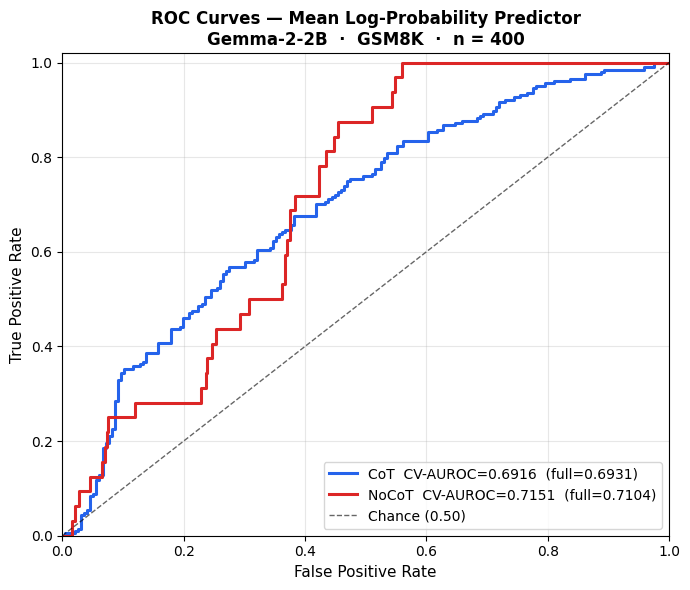

✓ Saved: /content/drive/MyDrive/experiments/exp3_logprob_mean/backup/figures/fig2_roc_curves.png


In [ ]:
FIG2_PATH = FIGURES_DIR / 'fig2_roc_curves.png'

if FIG2_PATH.exists():
    print(f'ROC curve plot already saved → loading from disk: {FIG2_PATH}')
    from IPython.display import Image, display
    display(Image(str(FIG2_PATH)))
else:
    COLORS = {'CoT': '#2563EB', 'NoCoT': '#DC2626'}

    fig, ax = plt.subplots(figsize=(7, 6))
    ax.set_title(
        'ROC Curves — Mean Log-Probability Predictor\n'
        'Gemma-2-2B  ·  GSM8K  ·  n = 400',
        fontsize=12, fontweight='bold',
    )

    for cond, df_resp in [('CoT', df_cot), ('NoCoT', df_nocot)]:
        y    = df_resp['correct'].astype(int).values
        lps  = df_resp['mean_lp'].values

        # Full-dataset curve (for visualization; CV-AUROC is the reported number)
        fpr, tpr, _ = roc_curve(y, lps)
        full_auc    = roc_auc_score(y, lps)

        # Cross-validated AUROC from LR results (Section 2)
        cv_auc = df_lr[df_lr.condition == cond.lower()].iloc[0]['auroc']

        ax.plot(fpr, tpr, color=COLORS[cond], linewidth=2.2,
                label=f'{cond}  CV-AUROC={cv_auc:.4f}  (full={full_auc:.4f})')

    ax.plot([0, 1], [0, 1], 'k--', linewidth=1.0, alpha=0.6, label='Chance (0.50)')
    ax.set_xlabel('False Positive Rate', fontsize=11)
    ax.set_ylabel('True Positive Rate', fontsize=11)
    ax.legend(fontsize=10, loc='lower right')
    ax.set_xlim([0, 1])
    ax.set_ylim([0, 1.02])
    ax.xaxis.set_major_formatter(mticker.FormatStrFormatter('%.1f'))
    ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.1f'))
    ax.grid(alpha=0.3)

    plt.tight_layout()
    fig.savefig(FIG2_PATH, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'✓ Saved: {FIG2_PATH}')

## 6. Statistical Tests — Mann-Whitney U

Non-parametric test comparing the `mean_lp` distributions of correct vs incorrect
responses within each condition.

- **H₀:** The distribution of `mean_lp` is identical for correct and incorrect responses.
- **H₁:** Correct responses have **higher** `mean_lp` (one-sided, `alternative='greater'`).

A significant result (p < 0.05) confirms that `mean_lp` carries reliable information
about correctness, independent of the linear-classifier AUROC.

Results saved to `cache/mw_tests.csv`.

In [ ]:
MW_PATH = CACHE_DIR / 'mw_tests.csv'

if MW_PATH.exists():
    df_mw = pd.read_csv(MW_PATH)
    print(f'Loaded cached Mann-Whitney results.')
else:
    records = []
    for cond, df_resp in [('cot', df_cot), ('nocot', df_nocot)]:
        correct_lps   = df_resp[df_resp.correct]['mean_lp'].dropna().values
        incorrect_lps = df_resp[~df_resp.correct]['mean_lp'].dropna().values

        # One-sided: H₁ is correct > incorrect (higher mean_lp for correct chains)
        stat, p_val = stats.mannwhitneyu(
            correct_lps, incorrect_lps, alternative='greater',
        )
        records.append({
            'condition':         cond,
            'n_correct':         len(correct_lps),
            'n_incorrect':       len(incorrect_lps),
            'mean_lp_correct':   float(correct_lps.mean()),
            'mean_lp_incorrect': float(incorrect_lps.mean()),
            'delta_mean':        float(correct_lps.mean() - incorrect_lps.mean()),
            'mw_statistic':      float(stat),
            'p_value':           float(p_val),
            'significant_05':    bool(p_val < 0.05),
        })

    df_mw = pd.DataFrame(records)
    df_mw.to_csv(MW_PATH, index=False)
    print(f'✓ Saved Mann-Whitney results → {MW_PATH}')

print('\n' + '═'*70)
print('  MANN-WHITNEY U TEST — H₁: mean_lp(correct) > mean_lp(incorrect)')
print('═'*70)
for _, row in df_mw.iterrows():
    sig_str = '✓ SIGNIFICANT' if row['significant_05'] else '✗ not significant'
    print(f'\n  [{row["condition"].upper():5s}]')
    print(f'    mean_lp  correct:   {row["mean_lp_correct"]:.4f}  (n={int(row["n_correct"])})')
    print(f'    mean_lp  incorrect: {row["mean_lp_incorrect"]:.4f}  (n={int(row["n_incorrect"])})')
    print(f'    Δ mean:             {row["delta_mean"]:+.4f}')
    print(f'    U = {row["mw_statistic"]:.0f},  p = {row["p_value"]:.4f}  →  {sig_str} (α = 0.05)')
print('═'*70)

✓ Saved Mann-Whitney results → /content/drive/MyDrive/experiments/exp3_logprob_mean/backup/cache/mw_tests.csv

══════════════════════════════════════════════════════════════════════
  MANN-WHITNEY U TEST — H₁: mean_lp(correct) > mean_lp(incorrect)
══════════════════════════════════════════════════════════════════════

  [COT  ]
    mean_lp  correct:   -0.0802  (n=204)
    mean_lp  incorrect: -0.1128  (n=196)
    Δ mean:             +0.0326
    U = 27713,  p = 0.0000  →  ✓ SIGNIFICANT (α = 0.05)

  [NOCOT]
    mean_lp  correct:   -0.0864  (n=32)
    mean_lp  incorrect: -0.1637  (n=368)
    Δ mean:             +0.0772
    U = 8366,  p = 0.0000  →  ✓ SIGNIFICANT (α = 0.05)
══════════════════════════════════════════════════════════════════════


## Results Summary

### Key Numbers

| Metric | CoT | NoCoT | Delta (CoT minus NoCoT) |
|---|---|---|---|
| Accuracy | **51.0%** (204/400) | **8.0%** (32/400) | -- |
| AUROC (mean_lp, 5-fold CV) | 0.6916 | 0.7151 | **-0.024** |
| Shuffled AUROC baseline | 0.458 | 0.581* | -- |
| Mann-Whitney p-value | 1.2e-11 | 3.9e-05 | -- |
| Significant (alpha=0.05)? | YES | YES | -- |
| mean_lp correct vs incorrect (delta) | +0.033 | +0.077 | -- |

*NoCoT shuffled baseline inflated above 0.50 due to extreme class imbalance (32 correct vs 368 incorrect).

---

### Interpretation

**1. Both conditions show a real but modest signal.**
AUROC of 0.692 (CoT) and 0.715 (NoCoT) are well above the shuffled baselines (~0.46 and ~0.50 respectively),
and both Mann-Whitney tests are highly significant (p=1.2e-11 and p=3.9e-05).
Correct responses do have systematically higher mean log-probability than incorrect ones in both conditions --
the model is, on average, more "fluent" when it gets the answer right.

**2. NoCoT mean_lp is a marginally stronger predictor than CoT (delta = -0.024).**
This is the opposite of what might be expected. The most likely explanation: CoT chains are much longer,
so many neutral/connective tokens ("therefore", "so", "the answer is") dilute the mean toward zero and
reduce the contrast between correct and incorrect chains. NoCoT responses are short and direct -- every token
counts -- making the mean a cleaner signal.

**3. This is the behavioral ceiling for a scalar logistic predictor.**
Compared to Exp1 (residual stream logistic regression, best AUROC = 0.800 at Layer 18 pos_A),
the mean_lp scalar sits ~0.11 AUROC points lower. The mechanistic representation in the residual
stream carries substantially more correctness information than the surface-level generation fluency.
This gap is the main argument for moving from behavioral to mechanistic analysis.

**4. Limitation: NoCoT class imbalance.**
With only 32 correct NoCoT responses, each CV fold has ~6 positives. The NoCoT AUROC (0.715)
is real but higher-variance, and its shuffled baseline (0.581) is itself inflated -- interpret with caution.

---

### Comparison to Exp1

| Experiment | Feature | AUROC (CoT) | AUROC (NoCoT) |
|---|---|---|---|
| **Exp3 (this)** | mean_lp scalar | 0.692 | 0.715 |
| **Exp1** | Residual stream L18, pos A | **0.800** | 0.682 |
| Shuffled baseline | -- | ~0.46 | ~0.46-0.58 |

The residual stream at layer 18 after CoT generation (Exp1) outperforms the mean_lp scalar by +0.108 AUROC points.
This confirms that the internal mechanistic representation adds discriminative power beyond surface generation fluency.

---

### Output Files

| File | Status |
|---|---|
| backup/cache/lr_results.csv | Saved |
| backup/cache/comparison_table.csv | Saved |
| backup/cache/mw_tests.csv | Saved |
| backup/figures/fig1_logprob_distribution.png | Saved |
| backup/figures/fig2_roc_curves.png | Saved |